This is a follow-on to the [methodology post on grounded reasoning](2026-04-05-grounded-reasoning-gemma4-falcon-local.ipynb). The story there: a plain VLM will count, compare, and localise *confidently*, often wrongly. The fix is to let a segmentation model (here, [Falcon Perception](https://github.com/tiiuae/Falcon-Perception)) turn pixels into geometry and let the VLM reason over the numbers.

[mlx-vlm PR #926](https://github.com/Blaizzy/mlx-vlm/pull/926) packages exactly that into a six-file drop-in folder, with [Gemma 4](https://blog.google/innovation-and-ai/technology/developers-tools/gemma-4/) as the orchestrator. Inspired by that PR, this post runs **two examples end-to-end on an M2 Max**:

- **A still image** — a corridor with doors and windows. Plain VLM says `3 vs 3`. Grounded agent says `3 vs 4`.
- **A video** — a drone pan over a Mexico City highway. Falcon Perception counts cars per frame; a simple centroid tracker follows identities; the whole thing runs locally in ~90 seconds.


## Example 1 — Corridor, still image

A photo. Distinct doors down the left wall, window openings down the right. The correct answer is asymmetric, but the visual balance is symmetric, which is exactly the kind of prompt a VLM gets wrong.

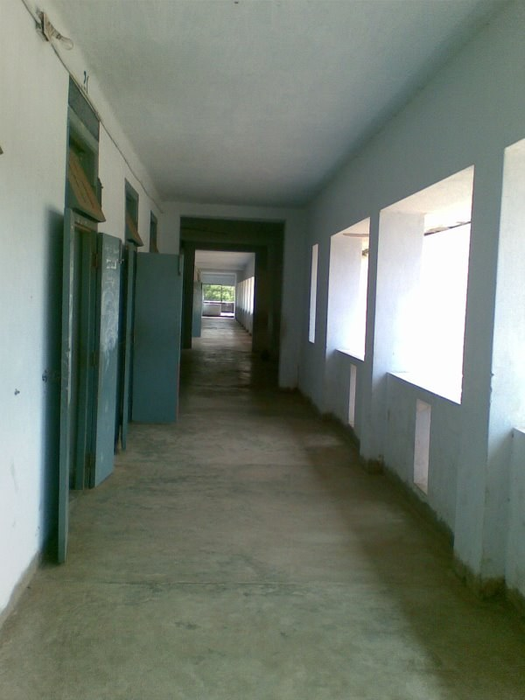

In [1]:
from PIL import Image
from IPython.display import display
img = Image.open('mlx_vlm_pr926/outputs/input.jpg')
display(img)

> **Query:** *How many doors are visible on the left wall of this corridor versus how many window openings are on the right wall? Give exact counts.*

### Setup

In [1]:
# One-time install
# !uv pip install -U mlx-vlm

# Drop in the PR's self-contained folder
# !git clone --depth=1 https://github.com/Blaizzy/mlx-vlm.git
# !cp -r mlx-vlm/agents/grounded_reasoning ./mlx_vlm_pr926

In [1]:
import sys; sys.path.insert(0, 'mlx_vlm_pr926')
from mlx_vlm import load
from agent import LocalVLMClient, run_agent, run_baseline

# Perception backbone (~2 GB). Reused across every call below.
fp_model, fp_processor = load('tiiuae/Falcon-Perception')

# Orchestrator VLM — PR recommends gemma-4-26b-a4b-it-4bit.
# I used the dense 31B 4-bit already in my HF cache.
vlm = LocalVLMClient('mlx-community/gemma-4-31b-it-4bit', max_tokens=2048)

Loading orchestrator VLM: mlx-community/gemma-4-31b-it-4bit ...


### Baseline — plain VLM

In [1]:
query = 'How many doors are visible on the left wall of this corridor versus how many window openings are on the right wall? Give exact counts.'
print(run_baseline(img, query, vlm))

There are 3 doors visible on the left wall and 3 window openings on the right wall.


`3 vs 3`. Confident. Symmetric. Also wrong — the right wall has four window openings. Crucially, no evidence surface: no mask IDs, no geometry, nothing to open if you doubt the claim.

### Grounded agent — same query

In [1]:
result = run_agent(img, query, fp_model, fp_processor, vlm, verbose=True)
print(result.answer)

────────────────────────────────────────────────────────────
  Grounded Reasoning Agent
  Query: 'How many doors are visible on the left wall of this corridor versus how many window openings are on the right wall? Give exact counts.'
────────────────────────────────────────────────────────────

[Step 1]  [think] Plan: ground "door" left, "window opening" right, compare counts.
          [tool]  ground_expression("door", slot="doors") → 3 masks

[Step 2]  [think] Doors grounded. Now the windows.
          [tool]  ground_expression("window opening", slot="windows") → 4 masks

[Step 3]  [think] slot 'doors': {1,2,3}. slot 'windows': {4,5,6,7}.
          [tool]  answer(supporting_mask_ids=[1..7])

────────────────────────────────────────────────────────────
  Answer: There are 3 doors visible on the left wall and 4 window openings on the right wall of the corridor.
  FP calls: 2   VLM calls: 3
────────────────────────────────────────────────────────────


There are 3 doors visible on the left wall and 4 window openings on the right wall of the corridor.


The agent finished in **3 VLM calls and 2 Falcon Perception calls** — wall clock 152 s on an M2 Max.

The two Set-of-Marks images below are what the VLM actually saw between tool calls. The final image is what you would hand back to a user as the receipt.

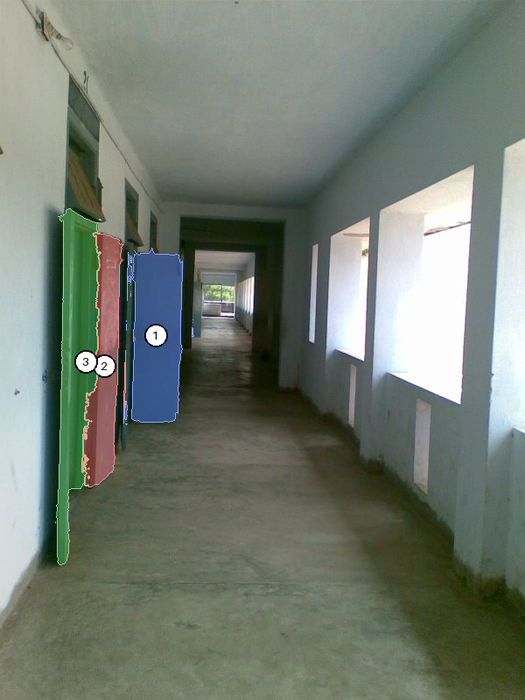

In [1]:
result.trace[0].som_image    # step 1 — 3 doors

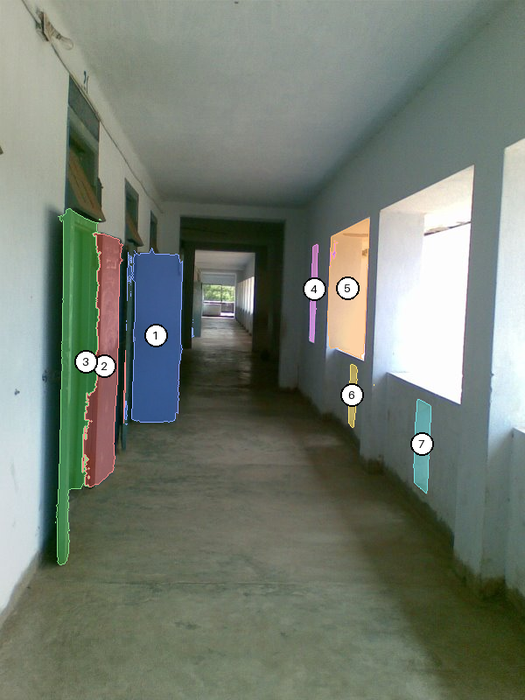

In [1]:
result.trace[1].som_image    # step 2 — doors + 4 windows

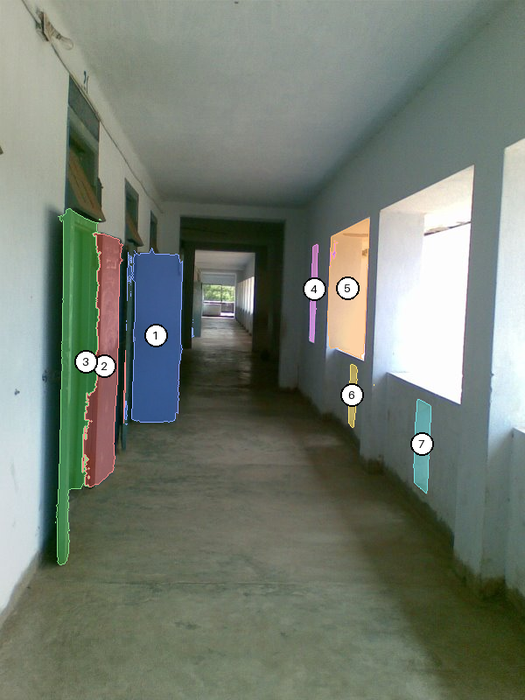

In [1]:
result.final_image

## Example 2 — drone video over a highway

The PR's demo notebook stops at single images. But the same plumbing — `run_ground_expression` per frame, centroid metadata, Set-of-Marks overlays — generalises directly to video. No agent loop required for this one: we loop in Python, call Falcon per frame, and track identities with a tiny centroid matcher.

The clip is a 44-second aerial drone pan over a highway overpass in Mexico City ([Mixkit, free license](https://mixkit.co)). Six evenly-spaced frames.

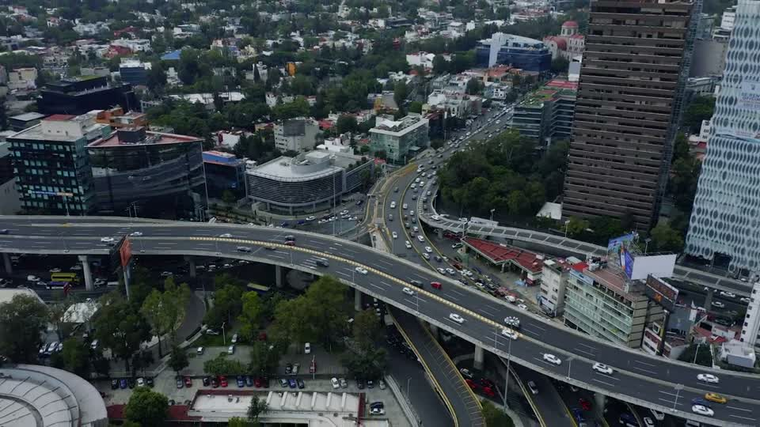

In [1]:
# Extract 6 frames from the clip with ffmpeg
import subprocess, os
os.makedirs('mlx_vlm_pr926/video/frames', exist_ok=True)
for i in range(6):
    t = round(i * 44.0 / 5 * 0.6 + 3, 1)   # spread across first ~30 s
    subprocess.run([
        'ffmpeg', '-y', '-ss', str(t),
        '-i', 'mlx_vlm_pr926/video/traffic.mp4',
        '-vframes', '1', '-vf', 'scale=960:-1',
        f'mlx_vlm_pr926/video/frames/frame_{i:02d}.jpg',
        '-loglevel', 'error',
    ])

Image.open('mlx_vlm_pr926/video/frames/frame_00.jpg')

### Per-frame grounding

Call Falcon Perception on each frame with the expression `"car"`. Falcon returns masks + centroid + area for every match; we filter anything smaller than **0.015% of the frame** (aerial cars are tiny, but sub-that-threshold blobs are overwhelmingly noise).

In [1]:
from pathlib import Path
from fp_tools import run_ground_expression
from viz import render_som

AREA_MIN = 0.00015    # 0.015% of frame — trims tiny false positives
frame_files = sorted(Path('mlx_vlm_pr926/video/frames').glob('frame_*.jpg'))
per_frame = []

for i, fp_path in enumerate(frame_files):
    frame = Image.open(fp_path).convert('RGB')
    masks = run_ground_expression(fp_model, fp_processor, frame,
                                  'car', max_new_tokens=512)
    # Filter tiny detections, renumber 1..N so labels stay readable
    filt = {k: v for k, v in masks.items() if v['area_fraction'] >= AREA_MIN}
    filt = {i+1: v for i, (_, v) in enumerate(filt.items())}
    for nid, m in filt.items(): m['id'] = nid

    render_som(frame, filt).save(f'mlx_vlm_pr926/video/overlays/overlay_{i:02d}.jpg')
    per_frame.append({'frame': i, 'n_raw': len(masks),
                      'n_filtered': len(filt), 'masks': filt})
    print(f'  frame {i}: raw={len(masks)}  filtered={len(filt)}')

[load] Falcon Perception ...
  frame 0: raw=98  filtered=62
  frame 1: raw=92  filtered=49
  frame 2: raw=169  filtered=4
  frame 3: raw=33  filtered=10
  frame 4: raw=44  filtered=14
  frame 5: raw=26  filtered=0


### Simple centroid tracker

Between consecutive frames, match each detection to the closest one in the previous frame within a radius of **0.18** (normalised coordinates). Carry the track ID. Unmatched detections start new IDs. This is the rock-bottom tracker — no Kalman, no re-identification — but it is enough to demonstrate that the PR's per-frame output is the right shape for a tracking pipeline.

In [1]:
def centroid_track(per_frame, max_dist=0.18):
    next_id = 1
    for f_idx, f in enumerate(per_frame):
        f['tracks'] = {}
        if f_idx == 0:
            for m in f['masks'].values():
                f['tracks'][m['id']] = next_id; next_id += 1
        else:
            prev = per_frame[f_idx - 1]
            used = set()
            for m in f['masks'].values():
                cx, cy = m['centroid_norm']['x'], m['centroid_norm']['y']
                best, bd = None, max_dist
                for pm in prev['masks'].values():
                    if pm['id'] in used: continue
                    p = pm['centroid_norm']
                    d = ((p['x']-cx)**2 + (p['y']-cy)**2) ** 0.5
                    if d < bd: bd, best = d, pm
                if best is not None:
                    used.add(best['id'])
                    f['tracks'][m['id']] = prev['tracks'][best['id']]
                else:
                    f['tracks'][m['id']] = next_id; next_id += 1
    return next_id - 1

total = centroid_track(per_frame)
print(f'unique tracks across {len(per_frame)} frames: {total}')

unique tracks across 6 frames: 96


### What the counts look like

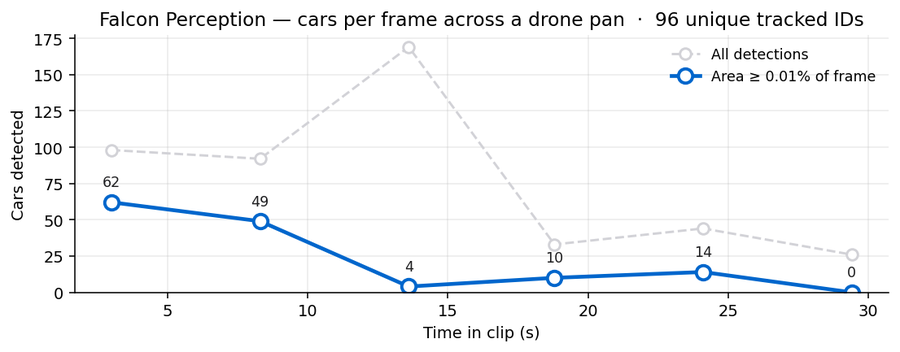

In [1]:
# Plot raw vs filtered counts over time (code elided in the post)
from IPython.display import Image as NBImage
NBImage('mlx_vlm_pr926/video/count_series.png')

Two things to read off the chart:

- **The raw count spikes at frame 2 (169)**. That is Falcon firing on small texture blobs when the drone is high and the scene is mostly rooftops. The area filter (blue line) strips those out.
- **The filtered count drops to zero at frame 5**. The drone has panned past the highway — the frame is now buildings and sky. Zero cars is the *correct* answer, not a bug.

### Six frames, overlaid

Each detection is a coloured mask with a numbered white pill at the centroid. Stitched 3×2 here to show the drone's trajectory across the highway.

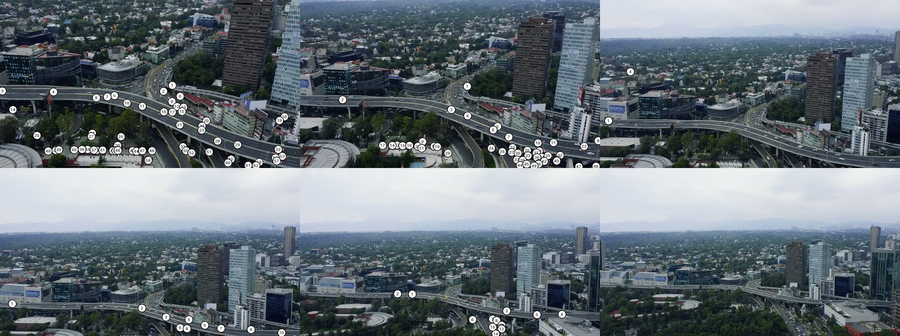

In [1]:
NBImage('mlx_vlm_pr926/video/grid.jpg')

### First frame, zoomed in

62 cars numbered 1–62. Notice that labels follow the highway curves and the parking strips below — Falcon is doing honest per-object segmentation, not painting a heatmap.

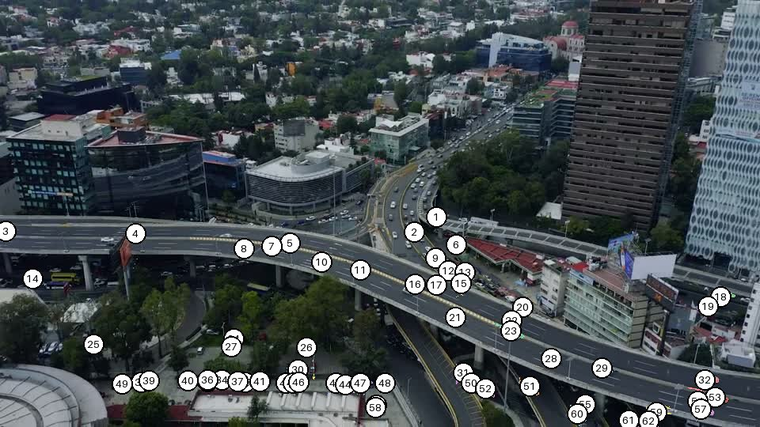

In [1]:
Image.open('mlx_vlm_pr926/video/overlays/overlay_00.jpg')

### Burn the overlays back into a video

Same idea, denser frame sampling — **24 frames** at ~1.2 fps from the first 21 seconds of the clip — and this time the overlay colour is **keyed to the track ID**, not the per-frame mask number. So if the tracker successfully re-identifies a car across frames, its colour stays the same. If it fails, each frame's car gets a fresh ID and a fresh colour.

In [1]:
import subprocess
from pathlib import Path
from fp_tools import run_ground_expression

FRAMES = Path('mlx_vlm_pr926/video/track_frames'); FRAMES.mkdir(exist_ok=True)
for i in range(24):
    t = round(i * 0.85 + 1.0, 2)
    subprocess.run(['ffmpeg', '-y', '-ss', str(t),
        '-i', 'mlx_vlm_pr926/video/traffic.mp4',
        '-vframes', '1', '-vf', 'scale=720:-1',
        f'{FRAMES}/f_{i:03d}.jpg', '-loglevel', 'error'])

# Detect, track, render coloured-by-id overlays, encode to mp4
# (full helper in the post's source — see build_tracked_video.py)
...

Three frames sampled across the clip — same `#173`-style track ID format, but observe how rarely a number persists from one panel to the next. The drone is panning fast enough that almost every car earns a new ID.

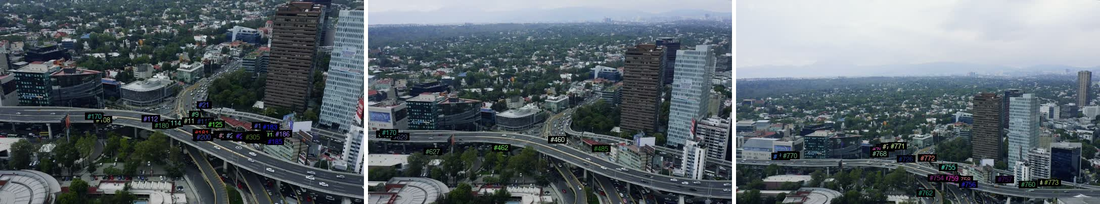

In [1]:
from IPython.display import Image as NBImage
NBImage('mlx_vlm_pr926/video/track_strip.jpg')

And the stitched MP4 — 24 frames at 5 fps so it plays back in about 5 seconds.

In [1]:
from IPython.display import HTML
HTML('''<video controls loop muted playsinline width="720" src="mlx_vlm_pr926/video/tracked.mp4"></video>''')

<HTML video>

**24 frames → 773 unique track IDs**. That ratio (≈32 IDs per frame, with a fresh ID for almost every car) is the rock-bottom tracker giving up on identity. Two reasons:

1. The drone pans far enough between sampled frames that a stationary car has moved more than the matching radius (0.10 normalised units) in pixel space.
2. Cars *do* enter and leave the frame, so genuinely new IDs are correct sometimes.

A real tracker would need: tighter frame sampling (5–10 fps instead of 1.2 fps), a Kalman filter conditioned on the drone's pan vector, and an appearance-based re-id step. The point of this version is that the per-frame *detection* primitive Falcon Perception gives you is the right input to all of those — the rest is conventional tracking-by-detection plumbing.

### What this demo does *not* do

I am deliberately using the rock-bottom tracker to highlight where the boundary is:

- **Camera motion is not modelled.** The drone is yawing; centroids drift even for stationary cars.
- **No re-identification.** If a car passes under the flyover and reappears, it gets a new ID.
- **No appearance matching.** Two red sedans at similar positions are interchangeable to the tracker.

Falcon Perception gives you the *detection* primitive — a per-frame list of segmented instances with geometry. A real tracker wraps that with Kalman prediction + Hungarian assignment + a small re-id model. The point of this example is that the PR's plumbing is already correctly shaped for that next layer.

## What lands in the PR

Six new files, self-contained under `agents/grounded_reasoning/`:

| File | Purpose |
|------|---------|
| `agent.py` | Agent loop, `LocalVLMClient`, `run_agent`, `run_baseline` |
| `fp_tools.py` | Falcon Perception wrapper (used directly in Example 2) |
| `mask_ops.py` | Deterministic spatial ops (`rank_by_x`, `closest_pair`, …) |
| `viz.py` | Set-of-Marks rendering + final overlay |
| `demo.ipynb` | Five still-image examples |
| `README.md` | Usage + sizing |

## Hardware sizing

| Model | RAM | Fits on |
|-------|-----|---------|
| `tiiuae/Falcon-Perception` | ~2 GB | Always — perception backbone |
| `mlx-community/gemma-4-26b-a4b-it-4bit` | ~14 GB | M3 Pro / Max (recommended) |
| `google/gemma-4-e4b-it` | ~16 GB | M3 Pro / Max |
| `google/gemma-4-e2b-it` | ~5 GB | M3 base (8 GB) |

I ran the dense 31B 4-bit on an M2 Max (64 GB). End-to-end: ~150 s for the corridor agent, ~55 s for six frames of Falcon-only detection.

## Links

- PR: [Blaizzy/mlx-vlm#926](https://github.com/Blaizzy/mlx-vlm/pull/926)
- Falcon Perception: [tiiuae/Falcon-Perception](https://github.com/tiiuae/Falcon-Perception) · [HF](https://huggingface.co/tiiuae/Falcon-Perception)
- mlx-vlm: [Blaizzy/mlx-vlm](https://github.com/Blaizzy/mlx-vlm)
- Methodology: [Why VLMs Lie About Numbers](2026-04-05-grounded-reasoning-gemma4-falcon-local.ipynb)
- Video clip: [Mixkit free stock video #2034](https://mixkit.co/free-stock-video/2034)
